In [1]:
import numpy as np
import pandas as pd 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



In [2]:
data = load_wine()

X = data.data 
y = data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
train_test_score = model.score(X_test, y_test)

print("Train-Test split accuracy:", train_test_score)

Train-Test split accuracy: 1.0


In [5]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X, y, cv=kfold)

print("K-Fold Cross-Validation accuracies:", kfold_scores)
print("K-Fold Cross-Validation mean accuracy:", kfold_scores.mean())    
print("K-Fold Variance:", np.var(kfold_scores))

K-Fold Cross-Validation accuracies: [1.         0.97222222 1.         0.97142857 1.        ]
K-Fold Cross-Validation mean accuracy: 0.9887301587301588
K-Fold Variance: 0.00019057697152935263


In [7]:
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=loo)

print("Leave-One-Out Cross-Validation mean accuracy:", loo_scores.mean())
print("Leave-One-Out Variance:", np.var(loo_scores))


Leave-One-Out Cross-Validation mean accuracy: 0.9831460674157303
Leave-One-Out Variance: 0.016569877540714557


In [8]:
methods = ["Train-Test Split", "K-Fold CV", "Leave-One-Out CV"]

mean_accuracy = [
    train_test_score,
    np.mean(kfold_scores),
    np.mean(loo_scores)
]

variance = [
    0,                         # single split → variance not measurable
    np.var(kfold_scores),
    np.var(loo_scores)
]

# Relative computational cost (conceptual scale)
computational_cost = [
    1,     # Train-test
    5,     # K-Fold (k=5)
    len(X) # LOOCV (N times)
]

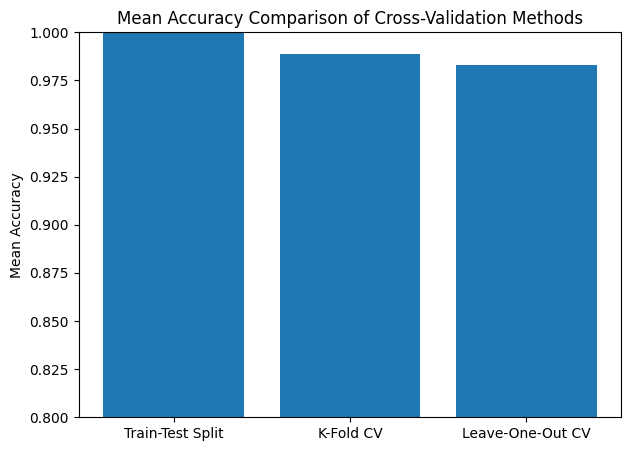

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(methods, mean_accuracy)
plt.ylim(0.8, 1.0)
plt.ylabel("Mean Accuracy")
plt.title("Mean Accuracy Comparison of Cross-Validation Methods")
plt.show()


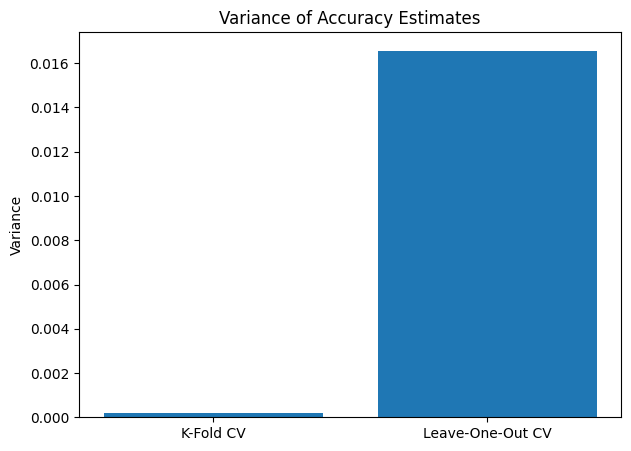

In [11]:
plt.figure(figsize=(7,5))
plt.bar(methods[1:], variance[1:])  # Train-test excluded
plt.ylabel("Variance")
plt.title("Variance of Accuracy Estimates")
plt.show()



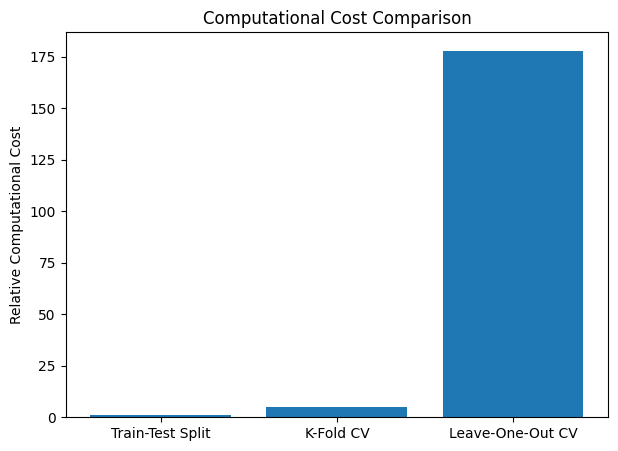

In [12]:
plt.figure(figsize=(7,5))
plt.bar(methods, computational_cost)
plt.ylabel("Relative Computational Cost")
plt.title("Computational Cost Comparison")
plt.show()

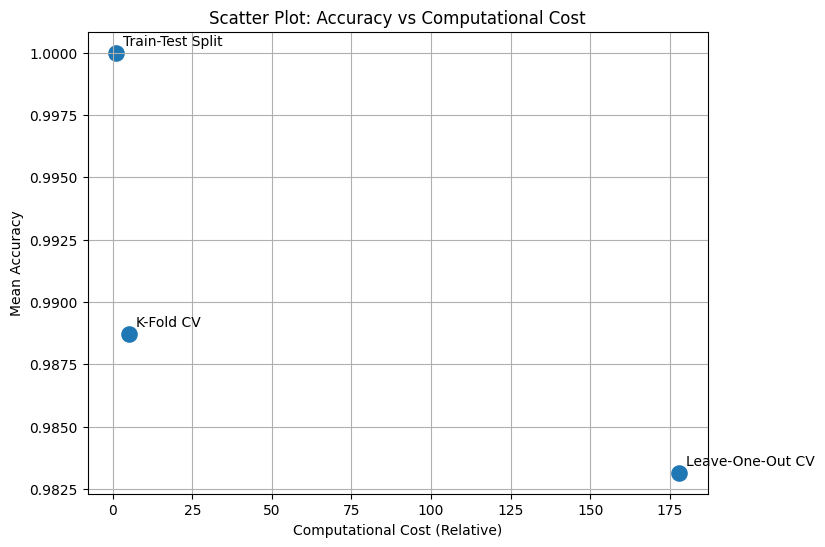

In [13]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["Train-Test Split", "K-Fold CV", "Leave-One-Out CV"]

mean_accuracy = [
    train_test_score,
    np.mean(kfold_scores),
    np.mean(loo_scores)
]

computational_cost = [
    1,        # Train-test
    5,        # K-Fold (k=5)
    len(X)    # LOOCV
]

plt.figure(figsize=(8,6))
plt.scatter(computational_cost, mean_accuracy, s=120)

# Annotate each point
for i, method in enumerate(methods):
    plt.annotate(method, 
                 (computational_cost[i], mean_accuracy[i]),
                 textcoords="offset points",
                 xytext=(5,5))

plt.xlabel("Computational Cost (Relative)")
plt.ylabel("Mean Accuracy")
plt.title("Scatter Plot: Accuracy vs Computational Cost")
plt.grid(True)
plt.show()
